In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# โหลดไฟล์ CSV
df = pd.read_csv("patient2025.csv")
df

,HN,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Marriage Status,Exercise (min/week),Living Area,stroke
0,11223,228.69,34.0,yes,201-220,71.00,1,1,Yes,0.0,Bangkok,1
1,8887,202.21,NaN,No,180-200,52.00,1,0,Yes,90.0,Country,1
2,5666,105.92,30.5,yes,180-200,78.00,1,1,Yes,0.0,Country,1
3,460182,171.23,35.0,No,221-260,54.00,1,0,Yes,0.0,Bangkok,1
4,166665,174.12,28.0,No,180-200,79.00,1,0,Yes,90.0,Country,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,60211,90.51,18.9,yes,Unknown,1.40,0,0,No,120.0,Bangkok,0
996,53279,118.87,16.3,yes,Unknown,0.24,0,0,No,120.0,Country,0
997,61715,56.42,31.8,yes,180-200,55.00,0,0,Yes,0.0,Country,0
998,37830,73.67,21.0,No,Unknown,29.00,0,0,No,0.0,Bangkok,0


# 1. Data Cleaning

In [3]:
# โหลดไฟล์ CSV
df = pd.read_csv("patient2025.csv")

# ลบคอลัมน์ที่ไม่จำเป็นออก: 'HN' คือหมายเลขผู้ป่วย ซึ่งเป็นตัวระบุและไม่มีผลต่อการทำนาย
df = df.drop('HN', axis=1)

# กำหนดค่าที่ขาดหายให้อยู่ในรูปแบบมาตรฐาน (NaN)
# ในไฟล์มีค่าขาดหายคือ 'N/A' (ใน BMI, Exercise) และ 'Unknown' (ใน Chorestorol)
df = df.replace(['N/A', 'Unknown'], np.nan)

df = df.rename(columns={'vegetarian (1= yes, 0=no)': 'vegetarian_status'})


print("Original Columns:", df.columns.tolist())

# --- จัดการ BMI (ตัวแปรเชิงปริมาณ) ---
# แปลงคอลัมน์ BMI เป็นตัวเลข (float) โดยกำหนดให้ค่าที่ไม่สามารถแปลงได้เป็น NaN
df['BMI'] = pd.to_numeric(df['BMI'], errors='coerce')
# เติมค่าว่างด้วยค่ามัธยฐาน (Median Imputation) ซึ่งทนทานต่อ Outliers
bmi_median = df['BMI'].median()
df['BMI'] = df['BMI'].fillna(bmi_median)
print(f"Filled BMI missing values with Median: {bmi_median:.2f}")

# --- จัดการ Exercise (min/week) (ตัวแปรเชิงปริมาณ) ---
# แปลงคอลัมน์ Exercise เป็นตัวเลข
df['Exercise (min/week)'] = pd.to_numeric(df['Exercise (min/week)'], errors='coerce')
# เติมค่าว่างด้วยค่ามัธยฐาน
exercise_median = df['Exercise (min/week)'].median()
df['Exercise (min/week)'] = df['Exercise (min/week)'].fillna(exercise_median)
print(f"Filled Exercise missing values with Median: {exercise_median:.1f}")

# --- จัดการ Chorestorol (ตัวแปรเชิงหมวดหมู่แบบอันดับ) ---
# เติมค่าว่างด้วยค่าฐานนิยม (Mode Imputation) เนื่องจากเป็นตัวแปรเชิงหมวดหมู่
chorestorol_mode = df['Chorestorol'].mode()[0]
df['Chorestorol'] = df['Chorestorol'].fillna(chorestorol_mode)
print(f"Filled Chorestorol missing values with Mode: {chorestorol_mode}")

Original Columns: ['FBS', 'BMI', 'Diabetes', 'Chorestorol', 'age', 'hypertension', 'vegetarian_status', 'Marriage Status', 'Exercise (min/week)', 'Living Area', 'stroke']
Filled BMI missing values with Median: 28.50
Filled Exercise missing values with Median: 0.0
Filled Chorestorol missing values with Mode: 180-200


In [4]:
df

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,vegetarian_status,Marriage Status,Exercise (min/week),Living Area,stroke
0,228.69,34.0,yes,201-220,71.00,1,1,Yes,0.0,Bangkok,1
1,202.21,28.5,No,180-200,52.00,1,0,Yes,90.0,Country,1
2,105.92,30.5,yes,180-200,78.00,1,1,Yes,0.0,Country,1
3,171.23,35.0,No,221-260,54.00,1,0,Yes,0.0,Bangkok,1
4,174.12,28.0,No,180-200,79.00,1,0,Yes,90.0,Country,1
...,...,...,...,...,...,...,...,...,...,...,...
995,90.51,18.9,yes,180-200,1.40,0,0,No,120.0,Bangkok,0
996,118.87,16.3,yes,180-200,0.24,0,0,No,120.0,Country,0
997,56.42,31.8,yes,180-200,55.00,0,0,Yes,0.0,Country,0
998,73.67,21.0,No,180-200,29.00,0,0,No,0.0,Bangkok,0


# 2. Feature Engineering

In [5]:
# --- Binary Encoding (สำหรับตัวแปร Yes/No) ---

# 1) Marriage Status: แปลง 'Yes' เป็น 1, 'No' เป็น 0
df['Marriage Status'] = df['Marriage Status'].map({'Yes': 1, 'No': 0})
# 2) Diabetes: แปลง 'yes' เป็น 1, 'No' เป็น 0
df['Diabetes'] = df['Diabetes'].map({'yes': 1, 'No': 0})

df['vegetarian_status'] = df['vegetarian_status'].astype(int)
df['hypertension'] = df['hypertension'].astype(int)


# --- Ordinal Encoding (สำหรับตัวแปรเชิงหมวดหมู่แบบอันดับ) ---
# กำหนดลำดับของระดับคอเลสเตอรอล
chorestorol_order = ['180-200', '201-220', '221-260']
# สร้าง OrdinalEncoder และ fit_transform
encoder = OrdinalEncoder(categories=[chorestorol_order])
df['Chorestorol_Encoded'] = encoder.fit_transform(df[['Chorestorol']])
# ลบคอลัมน์เดิมที่ไม่ใช่ตัวเลขออก
df = df.drop('Chorestorol', axis=1)
print("Chorestorol has been Ordinal Encoded.")


# --- One-Hot Encoding (สำหรับตัวแปรเชิงหมวดหมู่แบบไม่มีอันดับ) ---

# Living Area: มี 'Bangkok' และ 'Country' ใช้ One-Hot Encoding
df = pd.get_dummies(df, columns=['Living Area'], drop_first=True)
# drop_first=True ใช้เพื่อหลีกเลี่ยง Multicollinearity (สำหรับ Decision Tree อาจไม่จำเป็น
# แต่เป็นหลักปฏิบัติที่ดี)
df = df.rename(columns={'Living Area_Country': 'Living_Area_Country'})
print("Living Area has been One-Hot Encoded.")

Chorestorol has been Ordinal Encoded.
Living Area has been One-Hot Encoded.


In [6]:
df

,FBS,BMI,Diabetes,age,hypertension,vegetarian_status,Marriage Status,Exercise (min/week),stroke,Chorestorol_Encoded,Living_Area_Country
0,228.69,34.0,1,71.00,1,1,1,0.0,1,1.0,False
1,202.21,28.5,0,52.00,1,0,1,90.0,1,0.0,True
2,105.92,30.5,1,78.00,1,1,1,0.0,1,0.0,True
3,171.23,35.0,0,54.00,1,0,1,0.0,1,2.0,False
4,174.12,28.0,0,79.00,1,0,1,90.0,1,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...
995,90.51,18.9,1,1.40,0,0,0,120.0,0,0.0,False
996,118.87,16.3,1,0.24,0,0,0,120.0,0,0.0,True
997,56.42,31.8,1,55.00,0,0,1,0.0,0,0.0,True
998,73.67,21.0,0,29.00,0,0,0,0.0,0,0.0,False


# 3. Model Trainning

In [7]:
# 1. แยก Features (X) และ Target (y)
# เราจะใช้ 'stroke' เป็นตัวแปรที่ต้องการทำนาย
X = df.drop('stroke', axis=1)
y = df['stroke']

# 2. แบ่งข้อมูลเป็น Train และ Test set
# ใช้ stratify=y เพื่อให้สัดส่วนของผู้ที่เป็น/ไม่เป็น stroke ในชุด train และ test เท่าๆ กัน
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# 3. การทำ Feature Scaling
scaler = StandardScaler()
# คำนวณค่าเฉลี่ยและส่วนเบี่ยงเบนจากชุด Train แล้วนำไปปรับทั้ง Train และ Test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. สร้างและสอนโมเดล KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# 5. ทำนายผลและประเมินประสิทธิภาพ
y_pred = knn.predict(X_test_scaled)

print("--- ประสิทธิภาพของโมเดล KNN ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

--- ประสิทธิภาพของโมเดล KNN ---
Confusion Matrix:
[[339  37]
 [ 74  50]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       376
           1       0.57      0.40      0.47       124

    accuracy                           0.78       500
   macro avg       0.70      0.65      0.67       500
weighted avg       0.76      0.78      0.76       500

Accuracy Score: 0.7780


# 4. Tuning & Visualize Model

Optimal K found: 25


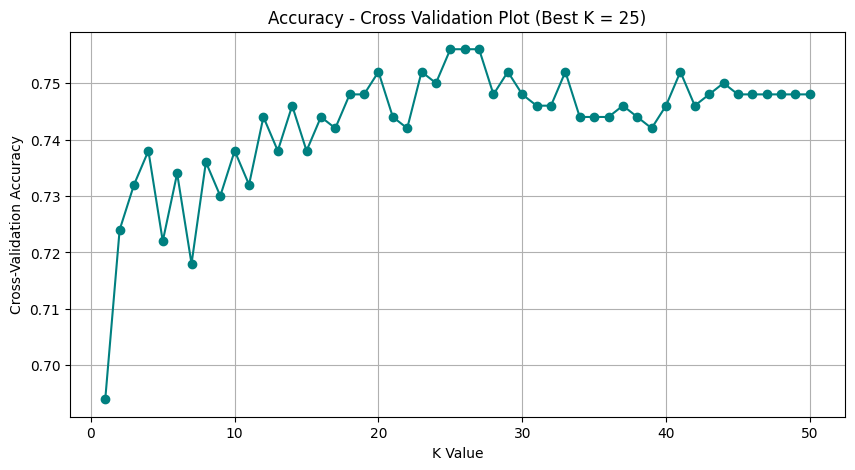

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters from GridSearch: {'metric': 'euclidean', 'n_neighbors': 25, 'weights': 'distance'}


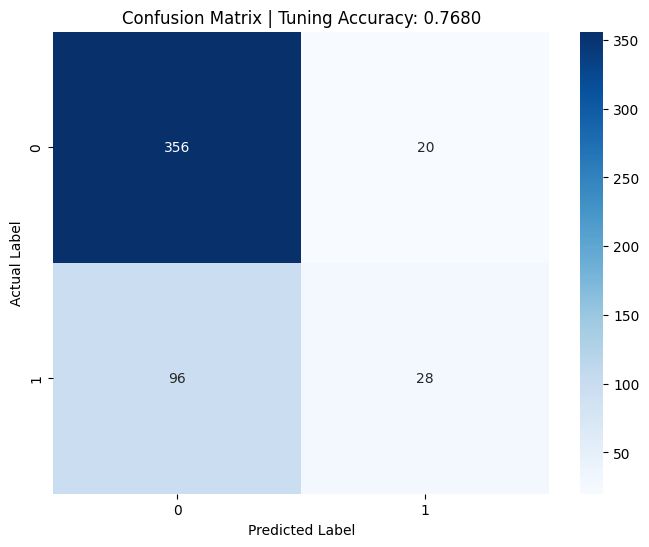


--- Final Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.95      0.86       376
           1       0.58      0.23      0.33       124

    accuracy                           0.77       500
   macro avg       0.69      0.59      0.59       500
weighted avg       0.74      0.77      0.73       500

Tuning Accuracy: 0.7680 (หรือ 76.80%)


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# --- 4.1 ค้นหาค่า K ที่เหมาะสมที่สุด (Optimal K) ---
# ทดสอบค่า k ในช่วง 1-50
k_values = range(1, 51)
cv_scores = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    # ทำ 5-fold cross-validation
    scores = cross_val_score(knn_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# หาค่า K ที่ให้ Accuracy สูงสุด
optimal_k = k_values[np.argmax(cv_scores)]
print(f"Optimal K found: {optimal_k}") # แสดงค่า K ที่ดีที่สุดที่หาเจอ

# พล็อตกราฟ Accuracy - Cross Validation Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='teal')
plt.title(f'Accuracy - Cross Validation Plot (Best K = {optimal_k})')
plt.xlabel('K Value')
plt.ylabel('Cross-Validation Accuracy')
plt.grid(True)
plt.show()

# --- 4.2 การจูนพารามิเตอร์ด้วย GridSearchCV ---
# กำหนดพารามิเตอร์ที่ต้องการทดสอบ
grid_params = {
    'n_neighbors': [3, 5, 11, 19, optimal_k],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# ใช้ n_jobs=None เพื่อป้องกัน Error บน Windows
gs = GridSearchCV(
    KNeighborsClassifier(),
    grid_params,
    cv=5,
    n_jobs=None,
    verbose=1
)

# เริ่มต้นการ Fit โมเดล
gs_results = gs.fit(X_train_scaled, y_train)

print(f"\nBest Parameters from GridSearch: {gs_results.best_params_}")

# --- 4.3 การแสดงผลและการวัดค่า Accuracy ---
# ใช้โมเดลที่ดีที่สุดมาพยากรณ์
best_knn = gs_results.best_estimator_
y_final_pred = best_knn.predict(X_test_scaled)

# คำนวณ Accuracy
tuning_acc = accuracy_score(y_test, y_final_pred)

# สร้าง Heatmap สำหรับ Confusion Matrix
cm = confusion_matrix(y_test, y_final_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix | Tuning Accuracy: {tuning_acc:.4f}') # แสดงในกราฟด้วย
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

print("\n--- Final Classification Report ---")
print(classification_report(y_test, y_final_pred))

# >>> ส่วนที่เพิ่ม: พิมพ์ค่า Tuning Accuracy ออกมาให้เห็นชัดๆ <<<
print("="*40)
print(f"Tuning Accuracy: {tuning_acc:.4f} (หรือ {tuning_acc*100:.2f}%)")
print("="*40)